# Sub-agents, Teams and the Discipline

Welcome to the fourth and last notebook of the Harness Engineering module. In notebook 01 you learned that an agent is a model plus a harness. In notebook 02 you took the harness apart: models, context, tools and skills. In notebook 03 you built one: the loop, its guardrails, the five workflow patterns and an eval suite that measured three configurations of the same agent. Today the question changes from *how do I build one agent* to *when do I need more than one*, and then to the question the whole module has been building towards: what does it mean to do this as a discipline?

In plain words: one driver can take one car anywhere, but a convoy needs a lead car, a shared route and a way to talk. This notebook builds the convoy (sub-agents), the team of drivers sharing one job board (agent teams), and the moment one driver hands the wheel to another (handoffs). Then it shows the ways convoys crash, and ends with the checklist harness engineers actually use.

**What you will learn**

- Why splitting the context across agents helps, with the numbers from Anthropic's multi-agent research system (13 Jun 2025).
- The difference between an orchestrator that is code and a lead agent that decides to delegate.
- How a flat agent team shares a task board and a mailbox, and how that differs from hierarchical sub-agents.
- What a handoff is and how it differs from delegation.
- The known failure modes: runaway loops, context pollution and cost multiplication.
- The discipline: instruction files, executable guards, evals in CI, observability and permission design.

**Sources used in this notebook** (the same texts sit in the agent's library, `harness/corpus/`): Anthropic, "How we built our multi-agent research system" (13 Jun 2025); Anthropic, "Effective context engineering for AI agents" (29 Sep 2025); OpenAI, "A practical guide to building agents" (Apr 2025); Anthropic, Claude Code documentation on subagents and agent teams (2025 to 2026); OpenAI, "Harness engineering" (11 Feb 2026); Marmelab, "The State of AI Harness Engineering 2026" (24 Sep 2026).

## How to run this notebook

- **Locally (Jupyter):** open this file in Jupyter and run the cells top to bottom.
- **Google Colab:** open the notebook from GitHub in [colab.research.google.com](https://colab.research.google.com) and run the cells top to bottom. The first cell downloads the small `harness` library (public files, no account, no key).

Running everything requires **no API key**. The course ships a `ScriptedModel`, a stand-in for a language model whose behaviour is a few lines of Python, so every run is repeatable and every printed number comes from the code above it. The *optional* section near the end shows how to plug in a real model behind the same interface; it is skipped unless you flip a switch and paste a key.

One note on the team section: teammates run in parallel threads, like a real team. Which teammate picks up which task depends on timing and may differ between runs. The results, the totals and the final answer do not.

In [1]:
# Setup: the notebooks use a small teaching library called `harness` that lives next to them
# in the repository. In Google Colab the folder is not there, so we download it (public files,
# no key, no account). Locally and in CI it is already present.
import pathlib, sys, urllib.request

REPO = "https://raw.githubusercontent.com/maglionejm/fontys-tech-exercises/main/M5%20-%20Harness%20Engineering/"
FILES = [
    "harness/__init__.py",
    "harness/agent.py",
    "harness/context.py",
    "harness/corpus/agent-skills.md",
    "harness/corpus/context-engineering.md",
    "harness/corpus/evals-and-observability.md",
    "harness/corpus/harness-effect.md",
    "harness/corpus/model-context-protocol.md",
    "harness/corpus/multi-agent-systems.md",
    "harness/corpus/prompt-to-harness-timeline.md",
    "harness/corpus/tool-design.md",
    "harness/corpus/what-is-a-harness.md",
    "harness/corpus/workflow-patterns.md",
    "harness/demo_tools.py",
    "harness/evals.py",
    "harness/messages.py",
    "harness/models.py",
    "harness/multi.py",
    "harness/patterns.py",
    "harness/policies.py",
    "harness/providers.py",
    "harness/skills.py",
    "harness/skills/cite-sources/SKILL.md",
    "harness/skills/cite-sources/checklist.md",
    "harness/skills/safe-calculations/SKILL.md",
    "harness/skills/summarize-brief/SKILL.md",
    "harness/skills/summarize-brief/template.md",
    "harness/tools.py",
    "harness/trace.py",
]
if not pathlib.Path("harness/__init__.py").exists():
    for name in FILES:
        target = pathlib.Path(name); target.parent.mkdir(parents=True, exist_ok=True)
        urllib.request.urlretrieve(REPO + name.replace(" ", "%20"), target)
    print(f"Downloaded the harness library ({len(FILES)} files).")
sys.path.insert(0, ".")
import harness
print("harness", harness.__version__, "ready")

harness 0.1.0 ready


## 1. Why split the context

Concrete anchor. A project lead who insists on reading every document the team reads is slower than the team, and worse at leading, because the details crowd out the overview. The same is true of an agent. The context window is a finite budget (notebook 02), and an agent that researches three questions in one context carries every search result and every document it read into every later step.

Anthropic's "Effective context engineering for AI agents" (29 Sep 2025) names the remedy: **sub-agent architectures**. A **sub-agent** is a fresh agent with a clean context, one focused task and a short report back. It may spend tens of thousands of tokens exploring and returns a summary of **1,000 to 2,000 tokens** to the lead. The lead keeps the summaries, not the exploration.

The production case is Anthropic's multi-agent research system (13 Jun 2025). A lead agent plans and spawns three to five sub-agents in parallel, each with its own context window and tools; a separate pass adds citations. On an internal research evaluation the system beat a single-agent setup by **90.2 percent**, at roughly **15 times the tokens** of a normal chat. The post's two lessons are the ones this notebook keeps returning to: **teach the orchestrator how to delegate** (clear task descriptions, boundaries, output format), and **scale effort to the complexity of the query** (one agent and a few calls for a simple fact; many agents for a broad question).

In the library, `SubAgentPool` creates isolated sub-agents from a factory and remembers what each one did. Its `delegate_tool()` gives the lead agent a `delegate` tool: the lead calls it with one sub-question, a fresh sub-agent runs the whole research loop of notebook 03, and only its answer comes back as the tool result. The lead's own policy, `lead_policy`, splits the question, calls `delegate` once per part in a single turn, then combines the reports. `context_size(result)` measures how big an agent's own context got.

In [2]:
import json
import pandas as pd
import matplotlib.pyplot as plt
from harness import Agent, ScriptedModel, Hooks
from harness.demo_tools import search_docs, read_doc, check_citation, calculator
from harness.policies import research_policy, lead_policy, planner_policy, synthesizer_policy, calculator_policy
from harness.patterns import orchestrate
from harness.multi import SubAgentPool, TaskBoard, Team, handoff, context_size
from harness.models import call, say

RESEARCH_TOOLS = [search_docs, read_doc, check_citation]
compound = ("When did Anthropic open-source the Model Context Protocol and what is progressive "
            "disclosure in Agent Skills and how much did Vercel reduce its tools?")

def make_research_agent(name="research"):
    """The research agent from notebook 03: search, read, check the citation, answer."""
    return Agent(ScriptedModel(research_policy, name="research"), tools=RESEARCH_TOOLS,
                 system="Answer from the library and cite the document you used.", name=name)

pool = SubAgentPool(lambda: make_research_agent("sub-agent"))
lead = Agent(ScriptedModel(lead_policy, name="lead"), tools=[pool.delegate_tool()],
             system="You coordinate research. Split compound questions, delegate one part per call, "
                    "then combine the reports and keep their citations.", name="lead")
lead_result = lead.run(compound)
print("Lead answer:\n" + lead_result.answer)

Lead answer:
Anthropic open-sourced the Model Context Protocol on 25 November 2024, with launch partners including Block and Apollo and development tool makers Zed, Replit, Codeium and Sourcegraph. [source: model-context-protocol] Anthropic introduced Agent Skills on 16 October 2025 in the post "Equipping agents for the real world with Agent Skills" and published the format as an open standard on 18 December 2025; by 2026 more than forty platforms support it. [source: agent-skills] Fewer tools often work better than more: in 2026 Vercel removed eighty percent of the tools from one of its agents, success rose from eighty percent to one hundred percent, token use halved, and latency fell from 724 seconds to 141 seconds. [source: tool-design]


Three parts, three cited sentences, one answer. Now look at what it cost, and where.

In [3]:
lead_context = context_size(lead_result)
print("Lead: final context =", lead_context, "| tokens its own model calls saw: ~", lead_result.tokens)
print("Sub-agents started:", len(pool.records), "| tokens they spent between them: ~", pool.tokens)
for i, rec in enumerate(pool.records, start=1):
    print(f"   sub-agent {i}: {rec.turns} turns, {len(rec.messages)} messages, ~{rec.tokens} tokens"
          f" -> {rec.answer[:55]!r}")
print()
lead_result.trace.show()

Lead: final context = {'messages': 6, 'tokens': 485} | tokens its own model calls saw: ~ 508
Sub-agents started: 3 | tokens they spent between them: ~ 5825
   sub-agent 1: 4 turns, 8 messages, ~1904 tokens -> 'Anthropic open-sourced the Model Context Protocol on 25'
   sub-agent 2: 4 turns, 8 messages, ~1933 tokens -> 'Anthropic introduced Agent Skills on 16 October 2025 in'
   sub-agent 3: 4 turns, 8 messages, ~1988 tokens -> 'Fewer tools often work better than more: in 2026 Vercel'

trace of 'lead': 2 model calls, 3 tool calls, ~508 tokens
   1  model    lead               delegate({'task': 'When did Anthropic open-source the Mod...
   1  tool     delegate           (task='When did Anthropic open-source the Model') -> Anth...
   1  tool     delegate           (task='what is progressive disclosure in Agent ') -> Anth...
   1  tool     delegate           (task='how much did Vercel reduce its tools?') -> Fewer t...
   2  model    lead               Anthropic open-sourced the Model Conte

The lead's trace has two model calls: one that delegates three times, one that combines. Everything else, the searching and reading, happened inside three separate contexts that the lead never saw. Compare that with a single agent given the same question:

In [4]:
solo_result = make_research_agent("solo").run(compound)
solo_context = context_size(solo_result)
print("Solo: final context =", solo_context, "| tokens: ~", solo_result.tokens)
print("Solo answer:\n" + solo_result.answer)

Solo: final context = {'messages': 8, 'tokens': 800} | tokens: ~ 2087
Solo answer:
Anthropic open-sourced the Model Context Protocol on 25 November 2024, with launch partners including Block and Apollo and development tool makers Zed, Replit, Codeium and Sourcegraph. An MCP server exposes tools, resources and prompts over a common message format; an MCP client, such as a chat application or a coding agent, can connect to any server without custom integration code. [source: model-context-protocol]


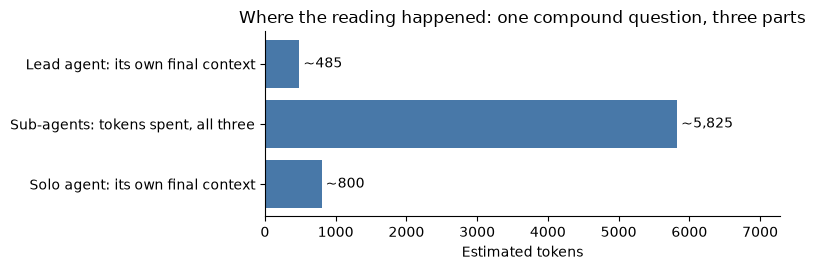

In [5]:
labels = ["Lead agent: its own final context", "Sub-agents: tokens spent, all three",
          "Solo agent: its own final context"]
values = [lead_context["tokens"], pool.tokens, solo_context["tokens"]]

fig, ax = plt.subplots(figsize=(8, 2.8))
bars = ax.barh(labels, values, color="#4878a8")
ax.invert_yaxis()
ax.set_xlim(0, max(values) * 1.25)
ax.set_xlabel("Estimated tokens")
ax.set_title("Where the reading happened: one compound question, three parts")
for bar, v in zip(bars, values):
    ax.text(v + max(values) * 0.01, bar.get_y() + bar.get_height() / 2, f"~{v:,}", va="center")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

How to read it: the first and third bars are the size of an agent's own context when it finished (the messages it carried). The middle bar is the total the three sub-agents spent across all their turns, which the lead never carried. The lead answered all three parts with a smaller context than the solo agent, which answered one. The work did not disappear; it moved into contexts that end when the sub-agent ends.

That is the whole argument for isolation in one picture: the lead stays small and coherent, the exploration happens elsewhere, and the bill is the sum of both. Section 5 comes back to the bill.

## 2. Orchestrator-workers versus sub-agents as tools

Notebook 03 ran the orchestrator-workers pattern with `harness.patterns.orchestrate`: a planner produces subtasks, workers do them in parallel, a synthesizer combines. The lead agent in section 1 looks similar and is not. The difference is **who decides the shape of the work**.

- In `orchestrate`, **the code decides**. The sequence is fixed: plan, then work, then combine. The model fills in the subtasks, and that is all it may do. This is a workflow.
- With the `delegate` tool, **the model decides**. Delegation is just a tool call. The lead may delegate three times, once, or not at all; it may read a report and delegate again; nothing in the harness forces the shape. This is an agent, and OpenAI's guide calls it the **manager pattern**: agents used as tools of a central manager (OpenAI, "A practical guide to building agents", Apr 2025).

Predictability against flexibility. The workflow version is easier to test and cheaper to reason about; the agent version handles the compound question you did not anticipate. Our scripted lead happens to delegate exactly the subtasks the planner would produce, so we can compare the two on equal terms:

In [6]:
planner = Agent(ScriptedModel(planner_policy, name="planner"), name="planner")
synthesizer = Agent(ScriptedModel(synthesizer_policy, name="synth"), name="synthesizer")
orc = orchestrate(planner, lambda: make_research_agent("worker"), synthesizer, compound)

delegated = [c.arguments["task"] for m in lead_result.messages if m.role == "assistant" for c in m.tool_calls]
print(f"orchestrate (code decides):   {len(orc['subtasks'])} subtasks, ~{orc['tokens']:,} tokens (workers + synthesizer)")
print(f"lead agent  (model decides):  {len(delegated)} delegations, ~{pool.tokens + lead_result.tokens:,} tokens (sub-agents + lead)")
print("same subtasks:", orc["subtasks"] == delegated)
print("same final text:", orc["final"].answer == lead_result.answer,
      "| answer lengths:", len(orc["final"].answer), "vs", len(lead_result.answer))

orchestrate (code decides):   3 subtasks, ~6,021 tokens (workers + synthesizer)
lead agent  (model decides):  3 delegations, ~6,333 tokens (sub-agents + lead)
same subtasks: True
same final text: True | answer lengths: 736 vs 736


Same subtasks, same workers, same reading; the token difference is the coordination overhead. The synthesizer makes one model call; the lead makes two, because deciding to delegate is itself a model call. That overhead is the price of flexibility, and it is small here because the scripted lead is decisive. A real lead that dithers, delegates the same thing twice or delegates when it should just answer pays much more, which is why "teach the orchestrator how to delegate" is the first lesson of the research system post.

## 3. Agent teams: a shared board and a mailbox

Concrete anchor: a kitchen during service. Nobody delegates each dish; orders go on a board, cooks pull the next ticket, and they shout across the pass when a dish depends on another. That is a **team**, and it is a different shape from the convoy of section 1.

Claude Code has both shapes. **Sub-agents** (generally available since 2025) are hierarchical: a sub-agent has an isolated context, works on one task, never talks to other sub-agents, and its result flows up to the agent that spawned it. **Agent teams** (a research preview from February 2026) are flat: several agents work in parallel from a shared task list, message one another directly, and a lead assigns tasks and synthesizes the results (Anthropic, Claude Code documentation, 2025 to 2026). Sub-agents suit a lead that knows the parts; teams suit a pile of work that nobody needs to sequence.

The library keeps the team small. A `TaskBoard` holds items that move from `todo` to `doing` to `done`; claiming is thread-safe, so two teammates never take the same task. A `Mailbox` carries direct messages. A `Team` has a lead, a dictionary of teammate factories and the board. When the team runs, every teammate loops: claim the next task, run a fresh agent on it, post the result to the board, mail the lead, repeat until the board is empty. Then the lead combines everything that got done. Below, six research questions from notebook 03's eval suite go on the board and three teammates clear it.

In [7]:
tasks = [
    "When did Anthropic open-source the Model Context Protocol?",
    "Which company adopted the Model Context Protocol in March 2025?",
    "When did Anthropic introduce Agent Skills?",
    "How many levels does progressive disclosure have in Agent Skills?",
    "By how much did Anthropic's multi-agent research system beat a single agent?",
    "How much did Vercel reduce its tools and what happened to success?",
]
board = TaskBoard(tasks)
print("Before the team starts:")
board.show()

team = Team(lead=Agent(ScriptedModel(synthesizer_policy, name="lead"), name="lead"),
            teammates={f"worker-{i}": (lambda: make_research_agent("teammate")) for i in range(1, 4)},
            board=board)
team_result = team.run()

print("\nAfter the team finishes:")
board.show()

Before the team starts:
#1 [todo ] -        When did Anthropic open-source the Model Context Protocol?
#2 [todo ] -        Which company adopted the Model Context Protocol in March 2025?
#3 [todo ] -        When did Anthropic introduce Agent Skills?
#4 [todo ] -        How many levels does progressive disclosure have in Agent Skills?
#5 [todo ] -        By how much did Anthropic's multi-agent research system beat a single 
#6 [todo ] -        How much did Vercel reduce its tools and what happened to success?

After the team finishes:
#1 [done ] worker-1 When did Anthropic open-source the Model Context Protocol?
#2 [done ] worker-2 Which company adopted the Model Context Protocol in March 2025?
#3 [done ] worker-3 When did Anthropic introduce Agent Skills?
#4 [done ] worker-3 How many levels does progressive disclosure have in Agent Skills?
#5 [done ] worker-1 By how much did Anthropic's multi-agent research system beat a single 
#6 [done ] worker-2 How much did Vercel reduce its tools 

In [8]:
print("tasks done:", len(board.done()), "of", len(board.items))
print("tasks per teammate:", {name: len(runs) for name, runs in team.results.items()})
print(f"tokens spent by the teammates: ~{team.tokens:,} | by the lead's final call: ~{team_result.tokens:,}")

print("\nmailbox:", len(team.mailbox.messages), "messages, all addressed to the lead")
for m in sorted(team.mailbox.messages, key=lambda m: int(m["text"].split("#")[1].split()[0])):
    print(f"   {m['from']} -> {m['to']}: {m['text'][:75]}...")

print("\nboard log, in the order it happened:")
print("   " + " | ".join(board.log))

print("\nLead's combined answer (first 300 characters):")
print(team_result.answer[:300] + " ...")

tasks done: 6 of 6
tasks per teammate: {'worker-3': 2, 'worker-1': 2, 'worker-2': 2}
tokens spent by the teammates: ~11,993 | by the lead's final call: ~394

mailbox: 6 messages, all addressed to the lead
   worker-1 -> lead: Task #1 done: Anthropic open-sourced the Model Context Protocol on 25 Novem...
   worker-2 -> lead: Task #2 done: On 26 March 2025 OpenAI announced support for MCP in its Agen...
   worker-3 -> lead: Task #3 done: Anthropic introduced Agent Skills on 16 October 2025 in the p...
   worker-3 -> lead: Task #4 done: Skills work through progressive disclosure, in three levels. ...
   worker-1 -> lead: Task #5 done: Anthropic's post "How we built our multi-agent research syste...
   worker-2 -> lead: Task #6 done: Fewer tools often work better than more: in 2026 Vercel remov...

board log, in the order it happened:
   worker-1 claimed #1 | worker-2 claimed #2 | worker-3 claimed #3 | worker-3 finished #3 | worker-3 claimed #4 | worker-1 finished #1 | worker-1 claimed #5 

Six tasks, six mails, one combined answer. Read the board log: the three teammates claimed one task each at the start, and whoever finished first took the next one. Nobody assigned anything; the board did. The split of tasks between teammates depends on timing and can differ when you re-run the cell, exactly as it would with real workers, while the total work and the total tokens stay the same.

Notice what the mailbox is for. In this small team it only carries "done" notices upward, which a hierarchy could do too. Its real value appears when teammate A discovers something teammate B needs mid-task and tells them directly, without going through the lead. That lateral channel is what sub-agents do not have, and it is also where teams get expensive: every message is more context for its reader.

## 4. Handoffs: passing the whole conversation

Concrete anchor: a phone call to customer service. First you talk to a general agent; when your problem turns out to be about billing, they transfer you, and the billing specialist can see everything you already said. You do not start over. That is a **handoff**: one agent passes the whole conversation to another and steps back.

OpenAI's guide names two shapes for multi-agent systems. In the **manager pattern**, one agent stays in charge and uses the others as tools; the manager keeps control and the conversation. That is sections 1 and 2. In the **decentralized pattern**, agents **hand off** control to one another; a handoff is a one-way transfer, and the receiving agent continues with the full history (OpenAI, "A practical guide to building agents", Apr 2025). In plain words: delegation says "go find this and report back"; a handoff says "you take it from here".

The library's `handoff(to_agent, history, instruction)` does exactly that: it runs the next agent with the previous conversation as its history and the instruction as the new user message. Below, a research conversation about the harness effect is handed to a calculator specialist. The numbers 891 and 179 may look familiar: they are the Titanic passengers and test rows from Module 2, so the result is the share of the data that was used for training.

In [9]:
research_run = make_research_agent("research").run(
    "What did Claude Opus 4.5 score on SWE-bench Pro under Claude Code?")
print("Research agent:", research_run.answer[:170], "...")
print("messages in that conversation:", len(research_run.messages))

calc = Agent(ScriptedModel(calculator_policy, name="calc"), tools=[calculator], name="calculator")
handed = handoff(calc, research_run.messages, "Now calculate (891-179)/891")
print("\nCalculator agent after the handoff:", handed.answer)
print("messages it holds:", len(handed.messages), "=", len(research_run.messages), "inherited +",
      len(handed.messages) - len(research_run.messages), "new")
fresh = Agent(ScriptedModel(calculator_policy, name="calc"), tools=[calculator], name="fresh-calculator")
fresh_run = fresh.run("Now calculate (891-179)/891")
print("tokens the first model call saw: after the handoff ~", handed.trace.model_calls()[0].tokens,
      "| in a fresh calculator agent ~", fresh_run.trace.model_calls()[0].tokens)
print()
handed.trace.show()

Research agent: On SWE-bench Pro, Claude Opus 4.5 scored 45.9 percent under the standardized SEAL scaffold and 55.4 percent under Claude Code, a 9.5 point gap for the identical model; th ...
messages in that conversation: 8

Calculator agent after the handoff: The result is 0.799102.
messages it holds: 12 = 8 inherited + 4 new
tokens the first model call saw: after the handoff ~ 715 | in a fresh calculator agent ~ 36

trace of 'calculator': 2 model calls, 1 tool calls, ~1442 tokens
   1  model    calc               calculator({'expression': '(891-179)/891'})
   1  tool     calculator         (expression='(891-179)/891') -> 0.799102
   2  model    calc               The result is 0.799102.
   2  final    calculator         The result is 0.799102.


The calculator agent answered a two-turn question, but its first model call saw several times the tokens a fresh calculator agent needs for the same arithmetic: the difference is the inherited research conversation. That is the trade-off of a handoff. The specialist has full context and the user never repeats themselves, but every handoff carries the baggage forward, and a specialist pays for tokens it does not need. Marmelab's 2026 survey found that problems requiring **more than four handoffs almost always failed**. Part of that is coordination, and part is simply that by the fifth handoff the conversation is long, mixed and stale. Section 5 makes that concrete.

## 5. Failure modes

Every architecture above has a way to fail that is specific to it. Three of them are common enough to have names, and a harness engineer builds against all three.

### 5.1 The runaway loop

A model that never feels done keeps calling tools. Nothing in the model stops it; only the harness can. The policy below imitates that failure: it searches the library again on every single turn. Watch two things in the trace: the `max_turns` stop that saves the run, and the token count of each model call, which grows every turn because every tool result stays in the context.

In [10]:
def runaway_policy(view):
    """A model that never feels done: it searches again every single turn."""
    return call("search_docs", query="harness", k=3)

runaway = Agent(ScriptedModel(runaway_policy, name="runaway"), tools=RESEARCH_TOOLS,
                max_turns=6, name="runaway").run("Tell me about harnesses")
print(runaway)
print()
runaway.trace.show()
per_turn = [e.tokens for e in runaway.trace.model_calls()]
print("\ncontext tokens the model saw, turn by turn:", per_turn)
print("growth per turn:", [b - a for a, b in zip(per_turn, per_turn[1:])], "| total sent: ~", sum(per_turn))

RunResult(answer='', turns=6, tokens~3114, stopped_because='max_turns')

trace of 'runaway': 6 model calls, 6 tool calls, ~3114 tokens
   1  model    runaway            search_docs({'query': 'harness', 'k': 3})
   1  tool     search_docs        (query='harness', k='3') -> [{"id": "harness-effect", "ti...
   2  model    runaway            search_docs({'query': 'harness', 'k': 3})
   2  tool     search_docs        (query='harness', k='3') -> [{"id": "harness-effect", "ti...
   3  model    runaway            search_docs({'query': 'harness', 'k': 3})
   3  tool     search_docs        (query='harness', k='3') -> [{"id": "harness-effect", "ti...
   4  model    runaway            search_docs({'query': 'harness', 'k': 3})
   4  tool     search_docs        (query='harness', k='3') -> [{"id": "harness-effect", "ti...
   5  model    runaway            search_docs({'query': 'harness', 'k': 3})
   5  tool     search_docs        (query='harness', k='3') -> [{"id": "harness-effect", "ti...
   6  mode

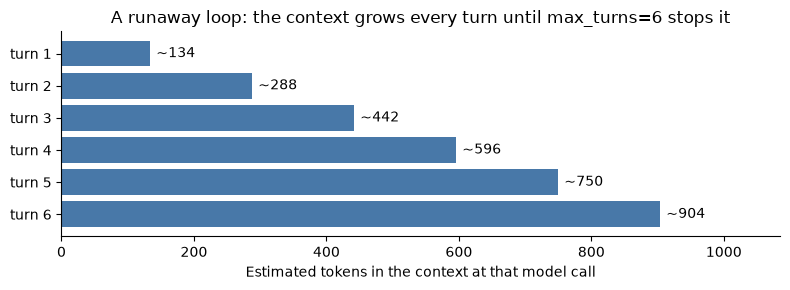

In [11]:
fig, ax = plt.subplots(figsize=(8, 3))
bars = ax.barh([f"turn {i}" for i in range(1, len(per_turn) + 1)], per_turn, color="#4878a8")
ax.invert_yaxis()
ax.set_xlim(0, max(per_turn) * 1.2)
ax.set_xlabel("Estimated tokens in the context at that model call")
ax.set_title(f"A runaway loop: the context grows every turn until max_turns={runaway.turns} stops it")
for bar, v in zip(bars, per_turn):
    ax.text(v + max(per_turn) * 0.01, bar.get_y() + bar.get_height() / 2, f"~{v}", va="center")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

How to read it: one bar per model call, in order; the length is the size of the context the model was sent that turn. Each turn adds the same search result again, so the bars grow by a constant step and the total bill grows with the square of the number of turns. With `max_turns=6` this run wasted a few thousand tokens and produced an empty answer. Without the seatbelt it would have run until the context window overflowed or the bill did. A budget stop (a cap on tokens or dollars per run) is the second seatbelt real harnesses add, and a trace is how you notice a runaway before the invoice does.

### 5.2 Context pollution

Section 1 showed the solo agent answering only the first part of the three-part question. Here is why. Its one search query mixed the key words of all three parts; the best-scoring document answered part one; the agent read it, verified it and stopped, and the other two parts vanished from the run without any error. Nothing failed loudly. That is **context pollution**: material from several tasks in one window, where the strongest signal wins and the rest is silently lost.

In [12]:
first_search = next(e.detail for e in solo_result.trace.tool_calls() if e.name == "search_docs")
print("Solo agent's single search:", first_search.split(" -> ")[0])
covered = {"part 1, the MCP date (mentions 2024)": "2024" in solo_result.answer,
           "part 2, progressive disclosure": "disclosure" in solo_result.answer.lower(),
           "part 3, the Vercel tool cut": "vercel" in solo_result.answer.lower()}
for part, ok in covered.items():
    print(f"   {'answered' if ok else 'missing '}  {part}")
print("Parts answered:", sum(covered.values()), "of", len(covered), "| stopped because:", solo_result.stopped_because)

Solo agent's single search: (query='anthropic open-source model context prot', k='3')
   answered  part 1, the MCP date (mentions 2024)
   missing   part 2, progressive disclosure
   missing   part 3, the Vercel tool cut
Parts answered: 1 of 3 | stopped because: done


The sub-agent design of section 1 is the cure: one part per context, so every part gets a clean search. The same failure appears in long single-agent sessions when a user changes topic and the old material keeps steering the search; compaction (notebook 02) and note-taking are the single-agent remedies.

### 5.3 Cost multiplication

Every agent that reads the same material pays for it again. Here is the bill for the three architectures in this notebook, using the numbers already computed above.

In [13]:
cost = pd.DataFrame([
    {"architecture": "Solo agent, one context", "questions answered": sum(covered.values()),
     "tokens": solo_result.tokens},
    {"architecture": "Lead + sub-agents", "questions answered": len(pool.records),
     "tokens": pool.tokens + lead_result.tokens},
    {"architecture": "Team of 3 on the six-task board", "questions answered": len(board.done()),
     "tokens": team.tokens + team_result.tokens},
]).set_index("architecture")
cost["tokens per answered question"] = (cost["tokens"] / cost["questions answered"]).round(0).astype(int)
cost["multiple of solo"] = (cost["tokens"] / cost.loc["Solo agent, one context", "tokens"]).round(1)
display(cost)

,questions answered,tokens,tokens per answered question,multiple of solo
architecture,,,,
"Solo agent, one context",1,2087,2087,1.0
Lead + sub-agents,3,6333,2111,3.0
Team of 3 on the six-task board,6,12387,2064,5.9


Read the last two columns together. The cost per answered question is roughly constant, about one research run each, because every answer needs its own search, read and check. What multiplies is the number of contexts doing that reading, plus the coordination on top. Anthropic's research system used about fifteen times the tokens of a chat for its 90.2 percent gain; that is a good trade for a hard research question and a terrible one for a simple lookup, which is what "scale effort to query complexity" means in practice.

Two more numbers from Marmelab's 2026 survey belong here, because they show that adding agents is not free even when the tokens are. Adding a **reviewer agent lowered the success rate by 8 percent** in one setup: the reviewer introduced disagreements and rework that a single well-verified agent did not need. And problems requiring **more than four handoffs almost always failed**. More agents means more coordination, and coordination is where multi-agent systems break. The rule of thumb this module has repeated since notebook 03 applies with extra force: start with the simplest thing that works, and add agents only when an eval shows they help.

## 6. The discipline

Everything in this module reduces to one habit: **do not ask the model to behave; build the thing that makes behaving the only option.** OpenAI's phrase for it is deterministic scaffolding around probabilistic model steps (Lopopolo, 11 Feb 2026). Here is the checklist harness engineers work from, with the survey numbers that show why each item exists (Marmelab, "The State of AI Harness Engineering 2026", 24 Sep 2026).

**1. Instruction files.** Standing rules live in a file the agent reads on every task (`CLAUDE.md`, `AGENTS.md`). Write them by hand and keep them short: human-written instruction files improved success by about 4 percent, while machine-generated ones did worse than no file at all. When everything is marked important, nothing is. Notebook 02 built the equivalent as the system prompt and the skill catalog.

**2. Executable guards.** Every rule that matters becomes a hook, a linter or a test, not a sentence. Of the security rules written into instruction files, **only 4.4 percent were backed by a real control**. Notebook 03's `before_tool` and `validate_answer` hooks, and the risk levels on tools, are what a real control looks like; OpenAI enforced its repository rules with custom linters and structural tests in CI.

**3. Evals in CI.** A suite of tasks with graders, including trap cases, runs on every change to a prompt, a tool or a model. **60 percent of harnesses ship without tests or evals**; the twelve-case suite of notebook 03 costs a few cents to run and caught the one failure a user could not see.

**4. Observability.** Every run leaves a trace: model calls, tool calls, denials, tokens, time. Every number in these four notebooks came out of a trace, including the ones that revealed the runaway loop and the polluted context above. Without traces, cost and failure are opinions.

**5. Permission design.** Tools carry risk levels; dangerous ones are denied by default and run in a sandbox when allowed; human approval is reserved for the rare decision. **93 percent of permission prompts get approved**, so an approval gate that fires often protects nothing.

**6. Effort that matches the task.** One agent for a lookup, sub-agents for a broad question, a team for a pile of independent work, and a cap on handoffs. More than four handoffs almost always failed; a reviewer agent cost 8 points. Delegation is taught, not assumed.

### The future

The discipline is young: Marmelab counted **21,500 "agent harness" repositories created in 2026**, with a median age of 8.7 months, and a source-code study of eleven coding agents found that the field runs on hand-rolled asynchronous loops and deterministic retrieval rather than general frameworks (Barbaste and colleagues, arXiv 2609.00006, Jul 2026). Three things seem settled. The **repository is becoming the system of record**: OpenAI's team shipped about one million lines of production code in five months with zero lines written by hand, because design documents, decision records and execution plans lived in the repo where the agent could read them. **Skills are becoming a standard**: the folder-with-a-SKILL.md format was published as an open standard in December 2025 and more than forty platforms support it. And **the harness is where the leverage is**: the same model scored 45.9 percent on SWE-bench Pro under one scaffold and 55.4 under another (arXiv 2609.11987, Sep 2026). The model is the engine. The harness is the rest of the car, and the car is what people drive.

### What you built: the eight pieces across four notebooks

| Piece of the harness | In plain words | What you built |
|---|---|---|
| 1. Model | The engine: context in, next message out | Notebook 01: a `ScriptedModel` with a few-line policy behind the same interface a real model uses. Notebooks 03 and 04: the optional switch to Claude or GPT through `providers.connect`. |
| 2. Context | Everything the model sees in one call, a finite budget | Notebook 02: the context window, its budget and compaction, and notes that survive it. Notebook 04: sub-agents that keep the lead's context small. |
| 3. Tools | Functions the model asks for by name; the harness runs them | Notebook 01: the first tool in a loop. Notebook 02: tool schemas, the registry, risk levels, and the library's search, read, calculator and citation checker. |
| 4. Skills | Folders of instructions, loaded on demand | Notebook 02: the skill index, its three levels of progressive disclosure, and the tokens each level costs. |
| 5. The loop | Gather context, take action, verify work, repeat, with stop conditions | Notebook 01: a loop written by hand. Notebook 03: `Agent.run()` with done, max turns and budget; the runaway loop in this notebook. |
| 6. Guardrails and permissions | Checks that run outside the model | Notebook 02: the default denial of dangerous tools. Notebook 03: `before_tool` and `validate_answer` hooks. Notebook 04: a cap on delegation (exercise 2). |
| 7. Orchestration | Workflows when the path is known, agents when it is not, sub-agents, teams, handoffs | Notebook 03: the five workflow patterns. Notebook 04: a lead with sub-agents, a team with a board, a handoff to a specialist. |
| 8. Evals and observability | A task, a grader, an outcome; a trace of every step | Notebook 01: the first trace. Notebook 03: a twelve-case suite over three configurations, and the bill. Notebook 04: token accounting per architecture. |

## 7. Optional: the same convoy on a real model

The lead, the sub-agents and the team never looked inside the model; they called `complete(system, messages, tools)` and read the reply. `harness/providers.py` offers Claude (`AnthropicModel`, default `claude-opus-5`) and GPT (`OpenAIModel`) behind that interface. `connect()` asks for your key with `getpass`, which hides what you type and keeps the key in memory only; it is never written to the notebook or the repository.

Set `RUN_REAL = True` and run the cell to let a real model lead the sub-agents on the compound question. Its trace will differ from the scripted one, and that is informative: count how many times it delegates, and whether it delegates the parts you would have.

In [14]:
RUN_REAL = False  # set True and run to try a real model

if RUN_REAL:
    from harness.providers import connect
    model = connect("anthropic")            # or connect("openai"); the key is asked for with getpass
    real_pool = SubAgentPool(lambda: Agent(model, tools=RESEARCH_TOOLS,
                                           system="Answer from the library and cite the document you used.",
                                           name="sub-agent"))
    real_lead = Agent(model, tools=[real_pool.delegate_tool()],
                      system="You coordinate research. Split compound questions, delegate one part per call, "
                             "then combine the reports and keep their citations.", name="lead")
    real_result = real_lead.run(compound)
    print(real_result.answer)
    real_result.trace.show()
    print("lead context:", context_size(real_result), "| sub-agents:", len(real_pool.records),
          "| sub-agent tokens:", real_pool.tokens)
else:
    print("RUN_REAL is False: skipped. Everything above ran without a key.")

RUN_REAL is False: skipped. Everything above ran without a key.


## 8. Key takeaways

- A **sub-agent** is a fresh agent with a clean context, one focused task and a short report back. The lead keeps summaries, not exploration: it answered three parts with a smaller context than a solo agent that answered one.
- **Orchestrator-workers** is a workflow: code decides the shape. **Sub-agents as tools** is an agent: the model decides when to delegate. Same reading, different locus of control, and the flexible version pays a coordination overhead.
- **Agent teams** are flat: a shared board, direct messages, a lead that synthesizes. **Sub-agents** are hierarchical: no lateral talk, results flow up. Teams suit piles of independent work; sub-agents suit a lead that knows the parts.
- A **handoff** transfers the whole conversation; delegation asks for a report. Handoffs carry baggage, and more than four almost always failed.
- The three failure modes are the **runaway loop** (only `max_turns` and a budget stop it), **context pollution** (the strongest signal wins, the rest is silently lost) and **cost multiplication** (every context that reads pays; a reviewer agent cost 8 points).
- The discipline is a checklist: instruction files, executable guards, evals in CI, observability, permission design, effort matched to the task. Do not ask the model to behave; build the thing that makes behaving the only option.

## 9. Practice exercises

Try these before looking at the solutions.

**Exercise 1 - A fourth teammate.** Rebuild the six-task board and run a `Team` with four teammates instead of three. Compare `team.tokens` and the number of tasks each teammate did with the three-teammate run. What changes, and what does not? Explain why in one sentence.

**Exercise 2 - Cap the delegations.** Write a `before_tool` hook that allows at most two `delegate` calls per run and denies the rest with a clear reason. Run the lead agent on the compound question with that hook. How many sub-agents started, and what happened to the third part of the answer?

**Exercise 3 - Make the runaway policy stop by itself.** Change `runaway_policy` so that it stops after one search and reports what it found (use `view.times_called("search_docs")` and `view.last_result("search_docs")`). Run it with the same `max_turns=6` and confirm that it now stops with `stopped_because="done"` in two turns.

## 10. Solutions

### Solution 1 - A fourth teammate

The total is identical. Six tasks need six research runs whether three or four workers do them, so the tokens are set by the work, not by the headcount. What changes is the spread of tasks across teammates and, with a real model, the wall-clock time: more teammates finish sooner, they do not read less.

In [15]:
board4 = TaskBoard(tasks)
team4 = Team(lead=Agent(ScriptedModel(synthesizer_policy, name="lead"), name="lead"),
             teammates={f"worker-{i}": (lambda: make_research_agent("teammate")) for i in range(1, 5)},
             board=board4)
team4_result = team4.run()

print("3 teammates: ~", team.tokens, "tokens | tasks each:", {n: len(r) for n, r in team.results.items()})
print("4 teammates: ~", team4.tokens, "tokens | tasks each:", {n: len(r) for n, r in team4.results.items()})
print("same total tokens:", team.tokens == team4.tokens, "| same number of mails:",
      len(team.mailbox.messages) == len(team4.mailbox.messages))

3 teammates: ~ 11993 tokens | tasks each: {'worker-3': 2, 'worker-1': 2, 'worker-2': 2}
4 teammates: ~ 11993 tokens | tasks each: {'worker-1': 2, 'worker-2': 2, 'worker-3': 1, 'worker-4': 1}
same total tokens: True | same number of mails: True


### Solution 2 - Cap the delegations

The hook counts `delegate` requests and denies the third. Our lead asks for all three parts in one turn, so the third request is refused before any sub-agent starts, and the lead's combined answer ends with the denial text instead of the Vercel fact. That is the honest outcome of a budget: something is left out, visibly. With a real model, the lead would read the denial and either merge two parts into one sub-question or answer the third part itself, which is why a cap should also be announced in the system prompt so the lead can plan for it.

In [16]:
delegate_calls = {"count": 0}

def cap_delegations(request, tool):
    if request.name == "delegate":
        delegate_calls["count"] += 1
        if delegate_calls["count"] > 2:
            return "the delegation budget of 2 sub-agents is spent; combine what you have"
    return None

capped_pool = SubAgentPool(lambda: make_research_agent("sub-agent"))
capped_lead = Agent(ScriptedModel(lead_policy, name="lead"), tools=[capped_pool.delegate_tool()],
                    hooks=Hooks(before_tool=[cap_delegations]), name="capped-lead")
capped = capped_lead.run(compound)

print("sub-agents started:", len(capped_pool.records), "| denied calls:", capped.trace.summary()["denied"],
      f"| tokens: ~{capped_pool.tokens + capped.tokens:,} (uncapped run: ~{pool.tokens + lead_result.tokens:,})")
print("end of the answer:", "..." + capped.answer[-110:])

sub-agents started: 2 | denied calls: 1 | tokens: ~4,223 (uncapped run: ~6,333)
end of the answer: ...pport it. [source: agent-skills] Denied: the delegation budget of 2 sub-agents is spent; combine what you have


### Solution 3 - Make the runaway policy stop by itself

The fix is a stop condition inside the policy: once a search has happened, report and finish. `max_turns` stays in place as the seatbelt; a well-behaved model just never needs it.

In [17]:
def careful_policy(view):
    """Searches once, then reports what it found and stops."""
    if view.times_called("search_docs") >= 1:
        hits = json.loads(view.last_result("search_docs"))
        return say(f"I searched once and found {len(hits)} documents: "
                   + ", ".join(h["id"] for h in hits) + ". Stopping here.")
    return call("search_docs", query="harness", k=3)

careful = Agent(ScriptedModel(careful_policy, name="careful"), tools=RESEARCH_TOOLS,
                max_turns=6, name="careful").run("Tell me about harnesses")
print(careful)
print("tokens: runaway ~", runaway.tokens, "| careful ~", careful.tokens)

RunResult(answer='I searched once and found 3 documents: harness-effect, prompt-to-harness-timelin', turns=2, tokens~422, stopped_because='done')
tokens: runaway ~ 3114 | careful ~ 422
